In [35]:
import pandas as pd
df = pd.read_csv("busson20.csv")

In [36]:
df["Day"] = (
    (df["TimeBlock"].eq(1) & df["TimeBlock"].shift().ne(1))
    .cumsum()
    + 1
)

In [44]:
pd.set_option("display.max_rows", 20000)

# In ra 10000 dòng đầu tiên của 2 cột
print(df[["TimeBlock","AveragePackets", "ActiveDevicesIP", "Day","DeviceScreenState"]].head(20000))

       TimeBlock  AveragePackets  ActiveDevicesIP  Day  DeviceScreenState
0              5       23.733333                5    1                  0
1              5       23.733333                5    1                  0
2              5       23.733333                5    1                  0
3              5       23.733333                5    1                  0
4              5       23.733333                5    1                  0
5              5       23.733333                5    1                  0
6              5       23.733333                5    1                  0
7              5       23.733333                5    1                  0
8              5       23.733333                5    1                  0
9              5       23.733333                5    1                  0
10             5       23.733333                5    1                  0
11             5       23.733333                5    1                  0
12             5       23.733333      

In [46]:
df_on = df[(df["DeviceScreenState"] == 1) | (df["DeviceScreenState"] == 0)]

In [47]:
result = (
    df_on
    .groupby(["Day"])
    .size()
    .reset_index(name="Count")
)


In [48]:
print (result)

   Day  Count
0    1   1660
1    2   2679
2    3   2735
3    4   2794
4    5   2807
5    6    375


In [50]:
import pandas as pd
df = pd.read_csv("Ryadh20.csv")

In [52]:
df["Day"] = (
    (df["Time Block"].eq(1) & df["Time Block"].shift().ne(1))
    .cumsum()
    + 1
)

In [ ]:
pd.set_option("display.max_rows", 20000)

# In ra 10000 dòng đầu tiên của 2 cột
print(df[["TimeBlock","AveragePackets", "ActiveDevicesIP", "Day","DeviceScreenState"]].head(20000))

In [53]:
df_on = df[(df["Device Screen State"] == 1) | (df["Device Screen State"] == 0)]

In [54]:
result = (
    df_on
    .groupby(["Day"])
    .size()
    .reset_index(name="Count")
)

In [55]:
print (result)

   Day  Count
0    1     79
1    2   3146
2    3   2862
3    4   1836


In [57]:
df["Day"] = (
    (df["Time Block"].eq(1) & df["Time Block"].shift().ne(1))
    .cumsum()
    + 1
)

In [59]:
df[["Time Block", "Day"]].head(1500)

,Time Block,Day
0,12,1
1,12,1
2,12,1
3,12,1
4,12,1
5,12,1
6,12,1
7,12,1
8,12,1
9,12,1


In [60]:
df_on = df[df["Device Screen State"] == 1]

In [61]:
result = (
    df_on
    .groupby(["Day", "Time Block"])
    .size()
    .reset_index(name="Count")
)

In [71]:
result1 = (
    df
    .groupby(["Day", "Time Block"])["Device Screen State"]
    .apply(lambda x: (x == 1).sum())  # đếm số dòng =1
    .reset_index(name="Count")
)

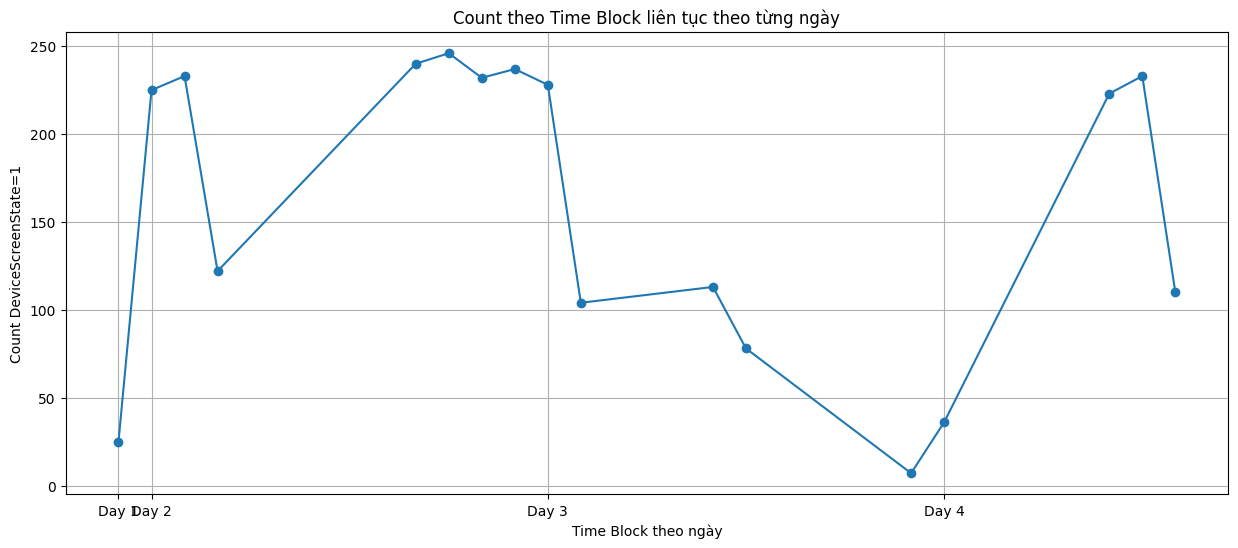

In [72]:
import matplotlib.pyplot as plt

# Giả sử 'result' đã có cột ['Day', 'Time Block', 'Count']

# Tạo trục x liên tục
result = result.sort_values(["Day", "Time Block"]).reset_index(drop=True)
result["x_pos"] = (result["Day"] - 1) * 12 + result["Time Block"]

plt.figure(figsize=(15,6))
plt.plot(result["x_pos"], result["Count"], marker="o")
plt.xlabel("Time Block theo ngày")
plt.ylabel("Count DeviceScreenState=1")
plt.title("Count theo Time Block liên tục theo từng ngày")

# Tuỳ chọn: đánh nhãn x theo ngày
# Chọn vị trí label là Time Block 1 của mỗi ngày
day_ticks = result.groupby("Day")["x_pos"].first()
plt.xticks(day_ticks, labels=[f"Day {d}" for d in day_ticks.index])

plt.grid(True)
plt.show()

plt.show()

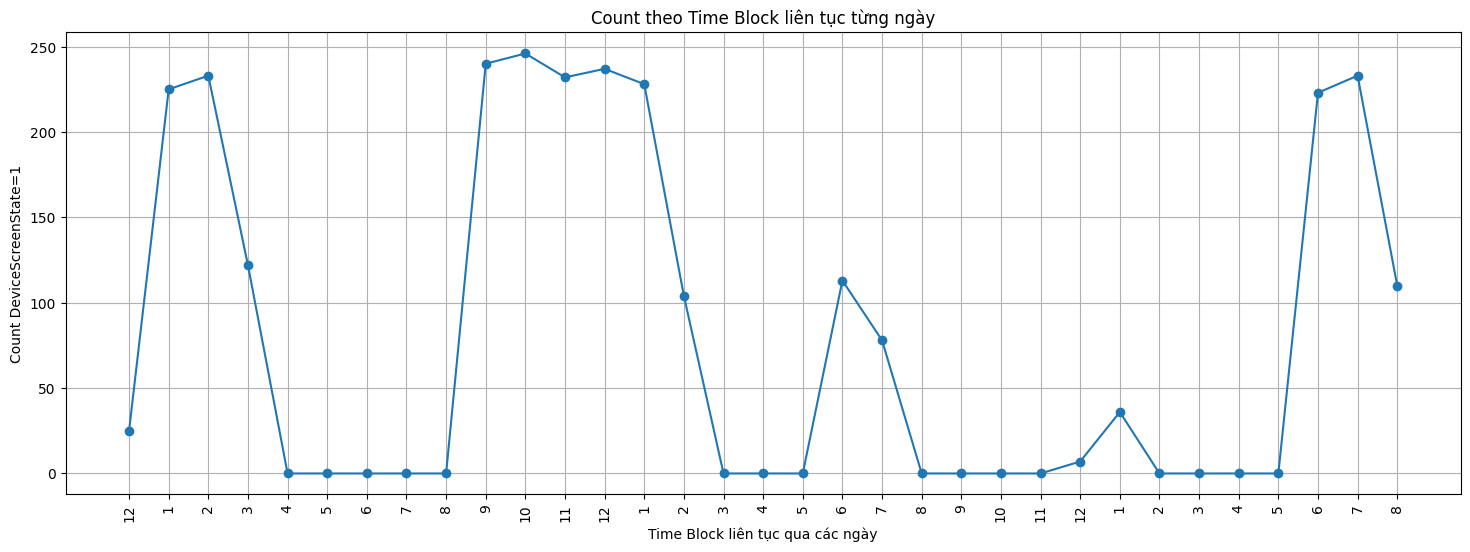

In [75]:
import matplotlib.pyplot as plt

# Sắp xếp theo Day và Time Block
result = result1.sort_values(["Day", "Time Block"]).reset_index(drop=True)

# Tạo trục x liên tục
result["x_pos"] = (result["Day"] - 1) * 12 + result["Time Block"]

plt.figure(figsize=(18,6))
plt.plot(result["x_pos"], result["Count"], marker="o")

plt.xlabel("Time Block liên tục qua các ngày")
plt.ylabel("Count DeviceScreenState=1")
plt.title("Count theo Time Block liên tục từng ngày")

# Hiển thị nhãn x cho từng Time Block
plt.xticks(result["x_pos"], [f"{tb}" for tb in result["Time Block"]], rotation=90)

plt.grid(True)
plt.show()


Busson

In [76]:
import pandas as pd
df = pd.read_csv("busson20.csv")

In [77]:
df1=df

In [79]:
df1["Day"] = (
    (df1["TimeBlock"].eq(1) & df1["TimeBlock"].shift().ne(1))
    .cumsum()
    + 1
)

In [80]:
result2 = (
    df1
    .groupby(["Day", "TimeBlock"])["DeviceScreenState"]
    .apply(lambda x: (x == 1).sum())  # đếm số dòng =1
    .reset_index(name="Count")
)

In [84]:
result2

,Day,TimeBlock,Count
0,1,5,0
1,1,6,0
2,1,7,0
3,1,8,0
4,1,9,0
5,1,10,74
6,1,11,223
7,1,12,186
8,2,1,208
9,2,2,229


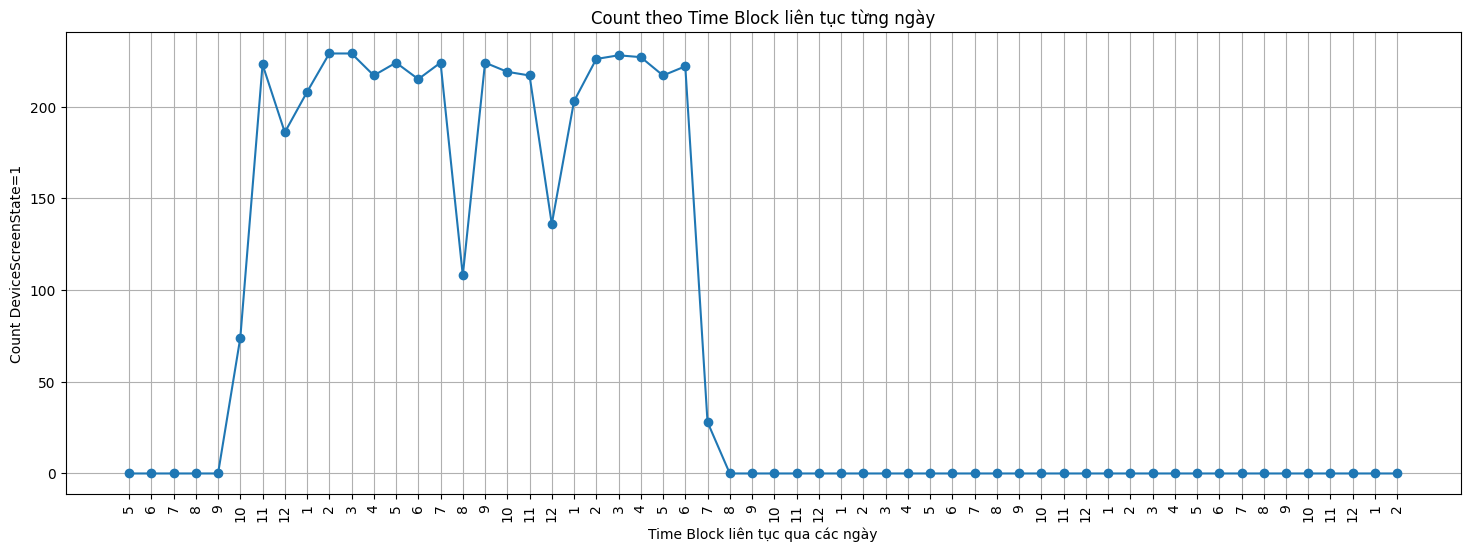

In [83]:
import matplotlib.pyplot as plt

# Sắp xếp theo Day và Time Block
result = result2.sort_values(["Day", "TimeBlock"]).reset_index(drop=True)

# Tạo trục x liên tục
result["x_pos"] = (result["Day"] - 1) * 12 + result["TimeBlock"]

plt.figure(figsize=(18,6))
plt.plot(result["x_pos"], result["Count"], marker="o")

plt.xlabel("Time Block liên tục qua các ngày")
plt.ylabel("Count DeviceScreenState=1")
plt.title("Count theo Time Block liên tục từng ngày")

# Hiển thị nhãn x cho từng Time Block
plt.xticks(result["x_pos"], [f"{tb}" for tb in result["TimeBlock"]], rotation=90)

plt.grid(True)
plt.show()